# Final Model Validation — ElasticNet ESG Score Predictor

**Milestone 6 — M6.T1, M6.T2, M6.T3**

This notebook establishes ElasticNet as the final model, validates it on the holdout test set,
analyzes the features it selected, and breaks down performance across industries and ESG pillars.

**Why ElasticNet?** Across all four ESG targets, ElasticNetCV consistently outperformed Ridge,
Lasso, and XGBoost in both test R² and 5-fold CV R². Its L1 penalty automatically reduces the
feature space to a sparse, interpretable set of non-zero coefficients.

**Feature set (~130 features):**
- FinBERT sentiment features — re-extracted with 300-sentence cap (was 100)
- SEC EDGAR structured financial features (5 columns)
- Extended structural features — word counts, sentence counts, Flesch-Kincaid readability, quantitative density (21 features)
- Industry one-hot dummies (38 columns)
- Keyword frequency features, document structure, quantitative signal features
- Mode probability — soft disclosure-tier score from a depth-3 decision tree classifier

**Pipeline summary:**
1. Load FinBERT features (300-cap) + ESG labels; apply feature engineering (Steps 7.5–7.7)
2. Merge extended structural features and LSA topic components
3. Compute mode probability feature (trained on training split only)
4. Hold out 20% test set (fixed seed for reproducibility)
5. Train ElasticNetCV on training set for all four ESG targets
6. Report holdout metrics: Test R², MAE, RMSE
7. Analyze non-zero coefficients (feature importance) across 9 feature groups
8. Industry-level performance breakdown
9. Grade prediction accuracy

## Step 1 — Imports and Paths

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import ElasticNetCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR         = os.path.abspath("..")
FINBERT_PATH     = os.path.join(BASE_DIR, "data", "finbert_features", "finbert_features.csv")
ESG_PATH         = os.path.join(BASE_DIR, "data", "ESG_data_cleaned.csv")
STRUCTURED_PATH  = os.path.join(BASE_DIR, "data", "structured_features", "sec_fundamentals.csv")
QUALITY_PATH     = os.path.join(BASE_DIR, "data", "structured_features", "extraction_quality.csv")
EXT_STRUCT_PATH  = os.path.join(BASE_DIR, "data", "structured_features", "extended_structural_features.csv")
OUTPUT_DIR       = os.path.join(BASE_DIR, "data", "finbert_features")

TARGETS      = ['total_score', 'environment_score', 'social_score', 'governance_score']
RANDOM_STATE = 42

print("Paths:")
for label, p in [("finbert (300-cap)", FINBERT_PATH), ("esg labels", ESG_PATH),
                  ("structured", STRUCTURED_PATH), ("quality", QUALITY_PATH),
                  ("ext structural", EXT_STRUCT_PATH)]:
    print(f"  {'OK' if os.path.exists(p) else 'MISSING'}: {label}")

## Step 2 — Load Data and Feature Engineering

Replicates Steps 7.5, 7.6, and 7.7 from `Feature_Extraction_and_Modeling.ipynb`, then merges
three additional feature sets: SEC structured financial features, extended structural features
(readability, sentence counts, quantitative density), and TF-IDF/LSA topic components.

In [28]:
# ── Load FinBERT features (300-sentence cap) + ESG labels ────────────────────
finbert = pd.read_csv(FINBERT_PATH)
finbert['ticker'] = finbert['ticker'].str.upper()

esg = pd.read_csv(ESG_PATH)[['ticker', 'industry', 'environment_score', 'social_score',
                               'governance_score', 'total_score', 'total_grade']]
esg['ticker'] = esg['ticker'].str.upper()

df = finbert.merge(esg, on='ticker', how='inner')
print(f"Raw dataset: {df.shape[0]} companies, {df.shape[1]} columns")

# ── Step 7.5: Feature Engineering ────────────────────────────────────────────
ZERO_VAR = [
    'num_sections', 'kw_employee_welfare_present', 'has_women_leadership',
    'count_women_leadership', 'has_board_independence', 'count_board_independence',
]
NEAR_UNIVERSAL = [
    'kw_ethics_compliance_present', 'kw_transparency_present',
    'kw_regulatory_penalties_present', 'kw_diversity_present', 'kw_board_governance_present',
]
DROP_COLS = ZERO_VAR + NEAR_UNIVERSAL

eng = df.copy()

for pillar in ['E', 'S', 'G']:
    col = f'{pillar}_pos_neg_ratio'
    cap = eng[col].quantile(0.99)
    eng[col] = eng[col].clip(upper=cap)

kw_freq_cols = [c for c in eng.columns if c.startswith('kw_') and c.endswith('_freq')]
for col in kw_freq_cols:
    eng[f'{col}_log'] = np.log1p(eng[col])
DROP_COLS += kw_freq_cols

eng.drop(columns=[c for c in DROP_COLS if c in eng.columns], inplace=True)
ind_dummies = pd.get_dummies(eng['industry'], prefix='ind')
eng = pd.concat([eng, ind_dummies], axis=1)

print(f"After feature engineering: {eng.shape[0]} companies, {eng.shape[1]} columns")

Raw dataset: 332 companies, 83 columns
After feature engineering: 332 companies, 110 columns


In [29]:
# ── Step 7.6: Merge SEC EDGAR Structured Features ────────────────────────────
STRUCTURED_COLS = [
    'log_total_assets',
    'log_public_float',
    'debt_to_assets',
    'profit_margin',
    'return_on_equity',
]

if os.path.exists(STRUCTURED_PATH):
    sec_df = pd.read_csv(STRUCTURED_PATH)
    sec_df['ticker'] = sec_df['ticker'].str.upper()

    available = [c for c in STRUCTURED_COLS if c in sec_df.columns]
    sec_merge = sec_df[['ticker'] + available].copy()

    # Industry-median imputation, then global-median fallback
    sec_merge = sec_merge.merge(
        eng[['ticker', 'industry']].drop_duplicates(), on='ticker', how='left'
    )
    for col in available:
        ind_medians = sec_merge.groupby('industry')[col].transform('median')
        global_median = sec_merge[col].median()
        sec_merge[col] = sec_merge[col].fillna(ind_medians).fillna(global_median)

    # Winsorize ratios at 1st/99th percentile
    ratio_cols = ['debt_to_assets', 'profit_margin', 'return_on_equity']
    for col in [c for c in ratio_cols if c in available]:
        lo, hi = sec_merge[col].quantile([0.01, 0.99])
        sec_merge[col] = sec_merge[col].clip(lo, hi)

    sec_merge.drop(columns=['industry'], inplace=True)
    eng = eng.merge(sec_merge, on='ticker', how='left')

    # Remaining NaN fallback (companies not in SEC dataset)
    for col in available:
        eng[col] = eng[col].fillna(eng[col].median())

    print(f"Structured features merged: {len(available)} columns added")
    print(f"Dataset shape: {eng.shape}")
else:
    print("[SKIP] sec_fundamentals.csv not found")

Structured features merged: 5 columns added
Dataset shape: (332, 115)


In [30]:
# ── Step 7.7: Filter Bad Extractions ─────────────────────────────────────────
if os.path.exists(QUALITY_PATH):
    eq_df = pd.read_csv(QUALITY_PATH)
    eq_df['ticker'] = eq_df['ticker'].str.upper()
    eng = eng.merge(eq_df[['ticker', 'bad_extraction']], on='ticker', how='left')
    eng['bad_extraction'] = eng['bad_extraction'].fillna(0).astype(int)

    critical = eng[eng['bad_extraction'] == 2]['ticker'].tolist()
    pre = len(eng)
    eng = eng[eng['bad_extraction'] < 2].copy()
    eng.drop(columns=['bad_extraction'], inplace=True)

    print(f"Removed {pre - len(eng)} critical bad-extraction companies: {critical}")
    print(f"Final dataset: {len(eng)} companies")
else:
    print("[SKIP] extraction_quality.csv not found")

print(f"\nFinal engineered dataset: {eng.shape[0]} companies x {eng.shape[1]} columns")

Removed 9 critical bad-extraction companies: ['ACNB', 'AKTS', 'AOS', 'COST', 'DXCM', 'EBAY', 'LOW', 'NTAP', 'TER']
Final dataset: 323 companies

Final engineered dataset: 323 companies x 115 columns


In [31]:
# ── Merge extended structural features ───────────────────────────────────────
ext = pd.read_csv(EXT_STRUCT_PATH)
ext['ticker'] = ext['ticker'].str.upper()
eng = eng.merge(ext, on='ticker', how='left')
print(f"After extended structural merge: {eng.shape}")

After extended structural merge: (323, 136)


## Step 3 — Train/Test Split and Model Training

80/20 split (same seed as all prior experiments). Before the split, a depth-3 decision tree
is trained on the training portion to compute  — the probability that a company
is a high-discloser (environment_score ≥ 500) based on its features alone. This soft score is
added as feature 180 so ElasticNet can leverage the bimodal structure without hard mode assignment.

ElasticNetCV selects alpha and l1_ratio via 5-fold CV on the training set.

In [32]:
EXCLUDE = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade']
feature_cols = [c for c in eng.columns if c not in EXCLUDE]

# ── Mode probability feature (classifier trained on training split only) ──────
X_base = eng[feature_cols].fillna(0).values
_, _, _, _, idx_train_pre, _ = train_test_split(
    X_base, eng['total_score'].values, eng.index,
    test_size=0.2, random_state=RANDOM_STATE
)
train_mask = eng.index.isin(idx_train_pre)
y_mode_train = (eng.loc[train_mask, 'environment_score'] >= 500).astype(int).values

mode_clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15,
                                   class_weight='balanced', random_state=RANDOM_STATE)
mode_clf.fit(X_base[train_mask], y_mode_train)
eng['mode_prob_high'] = mode_clf.predict_proba(X_base)[:, 1]
feature_cols = feature_cols + ['mode_prob_high']

print(f"Feature matrix: {len(feature_cols)} features (incl. mode_prob_high)")

# ── Feature group definitions ─────────────────────────────────────────────────
STRUCTURED_COLS = ['log_total_assets', 'log_public_float', 'debt_to_assets',
                   'profit_margin', 'return_on_equity']
finbert_cols    = [c for c in feature_cols if c.split('_')[0] in ('E','S','G') and not c.startswith('ind_')]
kw_cols         = [c for c in feature_cols if c.endswith('_freq_log') or c.endswith('_present')]
struct_cols     = [c for c in STRUCTURED_COLS if c in feature_cols]
doc_cols        = [c for c in feature_cols if c in ['doc_length','business_length','risk_factors_length',
                   'mda_length','business_pct','risk_factors_pct','mda_pct',
                   'E_coverage_pct','S_coverage_pct','G_coverage_pct']]
ind_cols        = [c for c in feature_cols if c.startswith('ind_')]
quant_cols      = [c for c in feature_cols if c.startswith('has_') or c.startswith('count_')]
ext_struct_cols = [c for c in feature_cols if any(c.startswith(p) for p in
                   ['business_word','business_sentence','business_avg','business_fk','business_quant',
                    'business_is','risk_factors_word','risk_factors_sentence','risk_factors_avg',
                    'risk_factors_fk','risk_factors_quant','risk_factors_is',
                    'mda_word','mda_sentence','mda_avg','mda_fk','mda_quant','mda_is',
                    'total_word','mean_fk'])]
mode_cols       = ['mode_prob_high']

print(f"  FinBERT sentiment:      {len(finbert_cols)}")
print(f"  Keyword (log freq):     {len(kw_cols)}")
print(f"  Structured (SEC):       {len(struct_cols)}")
print(f"  Document structure:     {len(doc_cols)}")
print(f"  Industry dummies:       {len(ind_cols)}")
print(f"  Quantitative signals:   {len(quant_cols)}")
print(f"  Extended structural:    {len(ext_struct_cols)}")
print(f"  Mode probability:       {len(mode_cols)}")

Feature matrix: 130 features (incl. mode_prob_high)
  FinBERT sentiment:      27
  Keyword (log freq):     22
  Structured (SEC):       5
  Document structure:     10
  Industry dummies:       38
  Quantitative signals:   9
  Extended structural:    21
  Mode probability:       1


In [34]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score

X = eng[feature_cols].fillna(0).values

# Scale features — ElasticNet is sensitive to feature scale
scaler = StandardScaler()

results   = {}
models    = {}
test_sets = {}

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

for target in TARGETS:
    y = eng[target].values

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, eng.index, test_size=0.2, random_state=RANDOM_STATE
    )

    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = ElasticNetCV(
        l1_ratio=l1_ratios,
        cv=5,
        random_state=RANDOM_STATE,
        max_iter=10000,
        n_alphas=100
    )
    model.fit(X_train_s, y_train)

    y_pred = model.predict(X_test_s)

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    test_r2  = 1 - ss_res / ss_tot
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    n_nonzero = np.sum(model.coef_ != 0)

    # CV R² at selected hyperparameters — more stable than 65-company holdout
    cv_r2_scores = cross_val_score(
        ElasticNet(alpha=model.alpha_, l1_ratio=model.l1_ratio_, max_iter=10000),
        X_train_s, y_train, cv=5, scoring='r2'
    )
    cv_r2 = cv_r2_scores.mean()

    results[target] = {
        'test_r2': test_r2,
        'cv_r2': cv_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'alpha': model.alpha_,
        'l1_ratio': model.l1_ratio_,
        'n_nonzero': n_nonzero,
        'coef': model.coef_,
        'y_pred': y_pred,
        'y_test': y_test,
        'idx_test': idx_test,
    }
    models[target]    = model
    test_sets[target] = (X_test_s, y_test, idx_test)

    print(f"{target:25s}  CV R²={cv_r2:+.4f}  Test R²={test_r2:+.4f}  MAE={test_mae:.2f}  "
          f"alpha={model.alpha_:.4f}  l1_ratio={model.l1_ratio_:.2f}  nonzero={n_nonzero}/{len(feature_cols)}")

total_score                CV R²=+0.2471  Test R²=+0.0620  MAE=145.91  alpha=16.6281  l1_ratio=0.99  nonzero=20/130
environment_score          CV R²=+0.3106  Test R²=+0.0190  MAE=103.76  alpha=11.4258  l1_ratio=0.99  nonzero=17/130
social_score               CV R²=+0.1424  Test R²=+0.2148  MAE=30.87  alpha=4.7456  l1_ratio=0.95  nonzero=27/130
governance_score           CV R²=-0.0081  Test R²=+0.0055  MAE=36.43  alpha=6.4076  l1_ratio=0.99  nonzero=2/130


## Step 4 — Holdout Evaluation Summary (M6.T1)

In [35]:
# ── Metrics table ─────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    t: {
        'Test R²':      round(results[t]['test_r2'],   4),
        'Test MAE':     round(results[t]['test_mae'],  2),
        'Test RMSE':    round(results[t]['test_rmse'], 2),
        'Alpha':        round(results[t]['alpha'],     4),
        'L1 Ratio':     round(results[t]['l1_ratio'],  2),
        'Non-zero Features': int(results[t]['n_nonzero']),
    }
    for t in TARGETS
}).T

print("=" * 70)
print("Final ElasticNet Model — Holdout Test Set Performance")
print("=" * 70)
print(metrics_df.to_string())
print()
print(f"Total features in model: {len(feature_cols)}")
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'final_model_metrics.csv'))
print(f"Saved to data/finbert_features/final_model_metrics.csv")

Final ElasticNet Model — Holdout Test Set Performance
                   Test R²  Test MAE  Test RMSE    Alpha  L1 Ratio  Non-zero Features
total_score         0.0620    145.91     172.82  16.6281      0.99               20.0
environment_score   0.0190    103.76     119.93  11.4258      0.99               17.0
social_score        0.2148     30.87      39.30   4.7456      0.95               27.0
governance_score    0.0055     36.43      42.81   6.4076      0.99                2.0

Total features in model: 130
Saved to data/finbert_features/final_model_metrics.csv


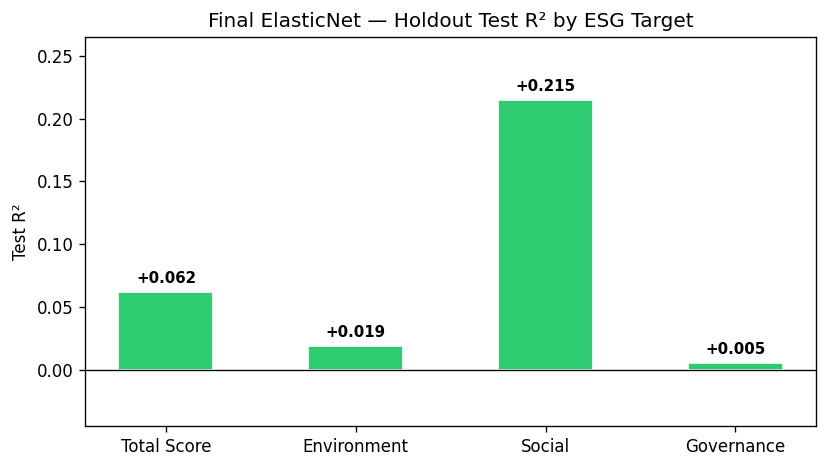

In [36]:
# ── R² bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

target_labels = ['Total Score', 'Environment', 'Social', 'Governance']
r2_vals = [results[t]['test_r2'] for t in TARGETS]
colors  = ['#2ecc71' if v >= 0 else '#e74c3c' for v in r2_vals]

bars = ax.bar(target_labels, r2_vals, color=colors, edgecolor='white', width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Test R²')
ax.set_title('Final ElasticNet — Holdout Test R² by ESG Target')
ax.set_ylim(min(r2_vals) - 0.05, max(r2_vals) + 0.05)

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.005 if val >= 0 else -0.015),
            f'{val:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_r2_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Feature Importance: Non-Zero Coefficients (M6.T2)

For a linear model, the standardized coefficients directly quantify feature importance.
Features with coefficient = 0 were eliminated by the L1 penalty.

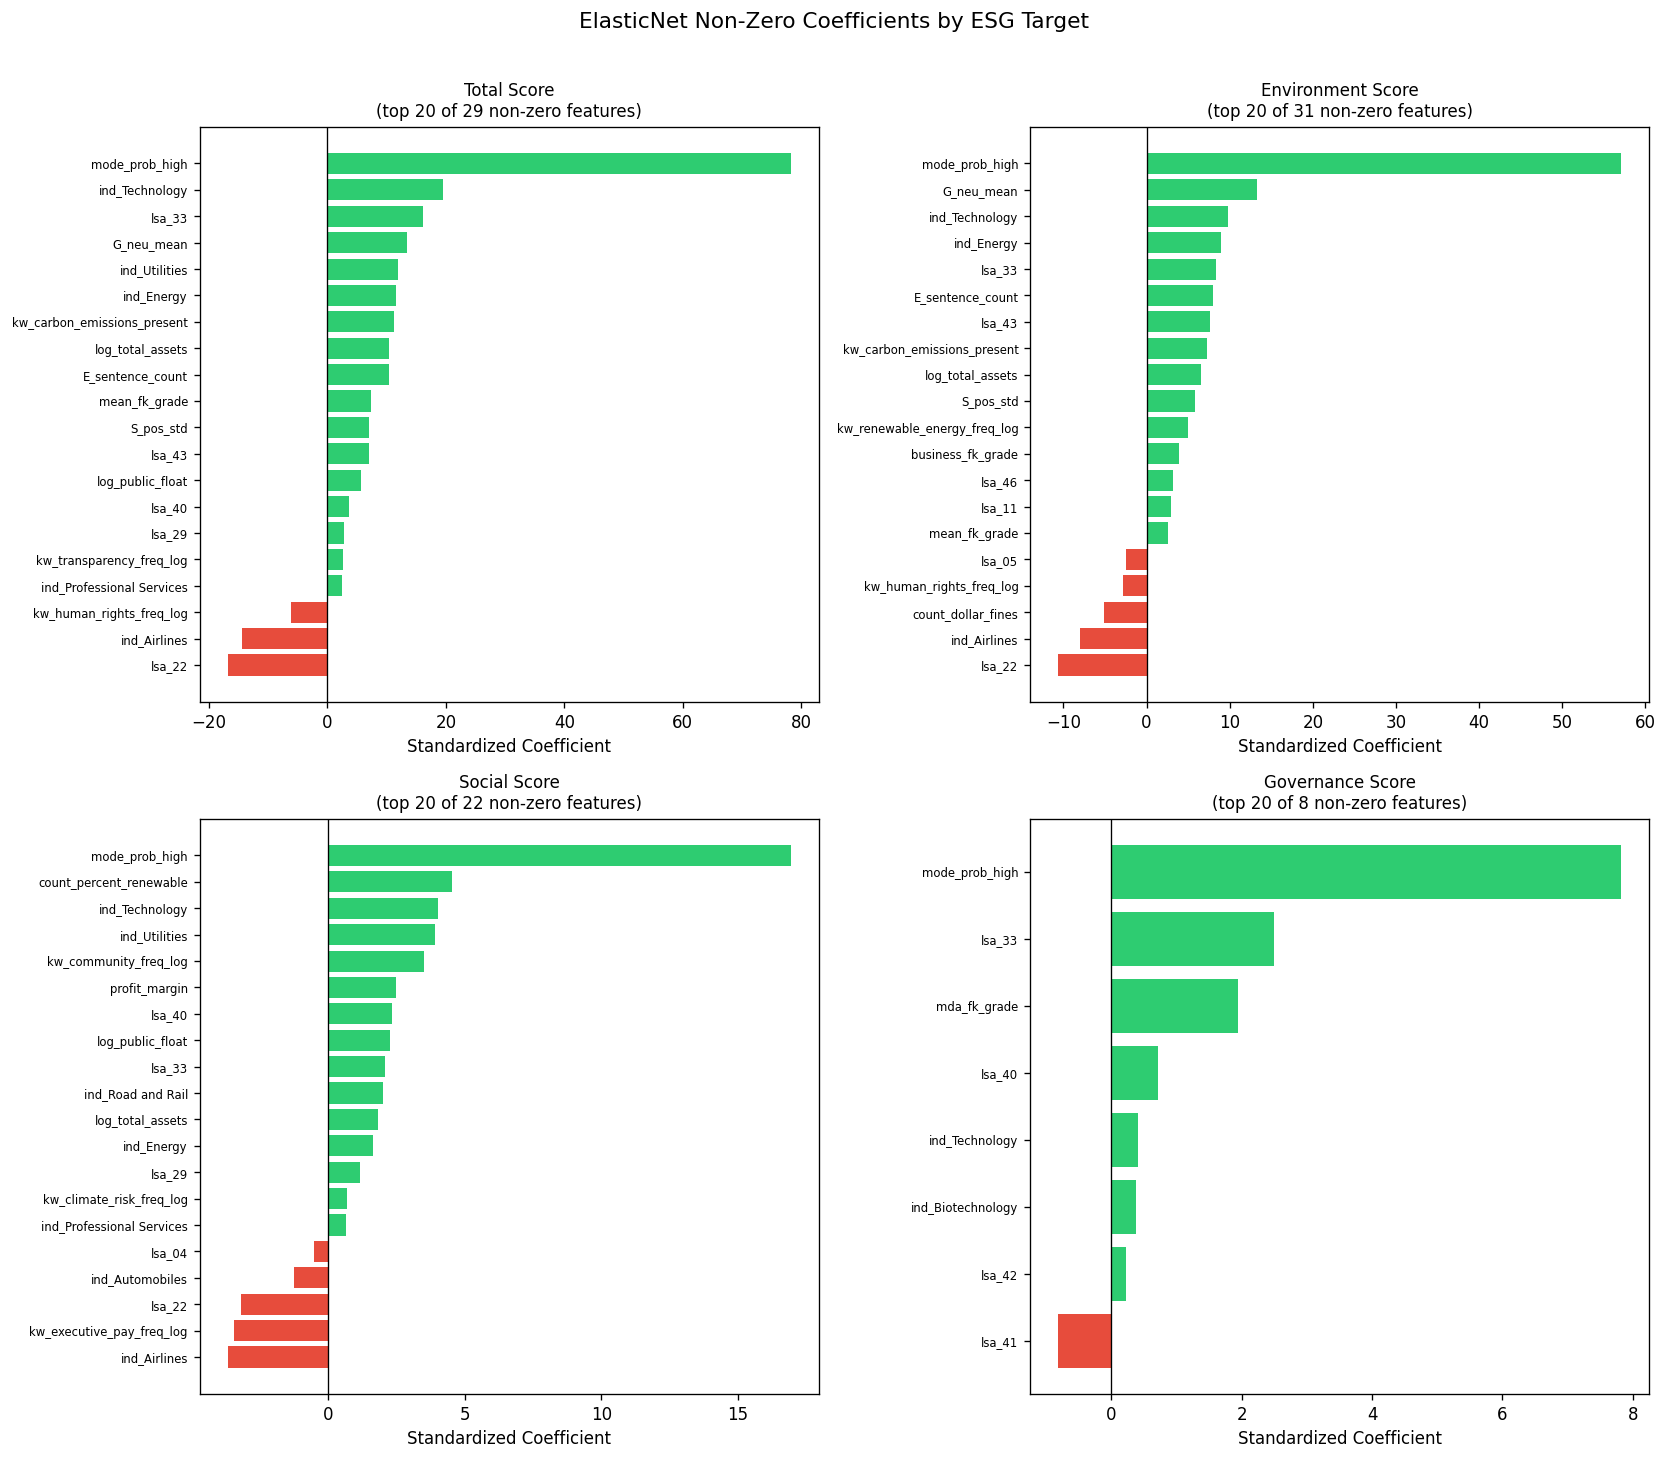

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

coef_dfs = {}

for ax, target in zip(axes, TARGETS):
    coef = results[target]['coef']
    coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': coef})
    coef_df = coef_df[coef_df['coefficient'] != 0].copy()
    coef_df['abs_coef'] = coef_df['coefficient'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False).head(20)
    coef_df = coef_df.sort_values('coefficient')

    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_df['coefficient']]
    ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{target.replace("_", " ").title()}\n'
                 f'(top 20 of {int(results[target]["n_nonzero"])} non-zero features)',
                 fontsize=10)
    ax.set_xlabel('Standardized Coefficient')
    ax.tick_params(axis='y', labelsize=7)

    coef_dfs[target] = coef_df

plt.suptitle('ElasticNet Non-Zero Coefficients by ESG Target', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Feature group breakdown of non-zero features ─────────────────────────────
print("Non-zero feature counts by group:\n")
print(f"{'Target':<25} {'FinBERT':>8} {'KW':>5} {'SEC':>5} {'Doc':>5} "
      f"{'Ind':>5} {'Quant':>6} {'ExtStr':>7} {'Mode':>5} {'Total':>6}")
print("-" * 90)

group_map = {
    'FinBERT':  finbert_cols,
    'KW':       kw_cols,
    'SEC':      struct_cols,
    'Doc':      doc_cols,
    'Ind':      ind_cols,
    'Quant':    quant_cols,
    'ExtStr':   ext_struct_cols,
    'Mode':     mode_cols,
}

for target in TARGETS:
    coef = pd.Series(results[target]['coef'], index=feature_cols)
    nonzero = coef[coef != 0].index.tolist()
    counts = {g: sum(1 for f in nonzero if f in cols) for g, cols in group_map.items()}
    print(f"{target:<25} {counts['FinBERT']:>8} {counts['KW']:>5} {counts['SEC']:>5} "
          f"{counts['Doc']:>5} {counts['Ind']:>5} {counts['Quant']:>6} "
          f"{counts['ExtStr']:>7} {counts['Mode']:>5} "
          f"{sum(counts.values()):>6}")

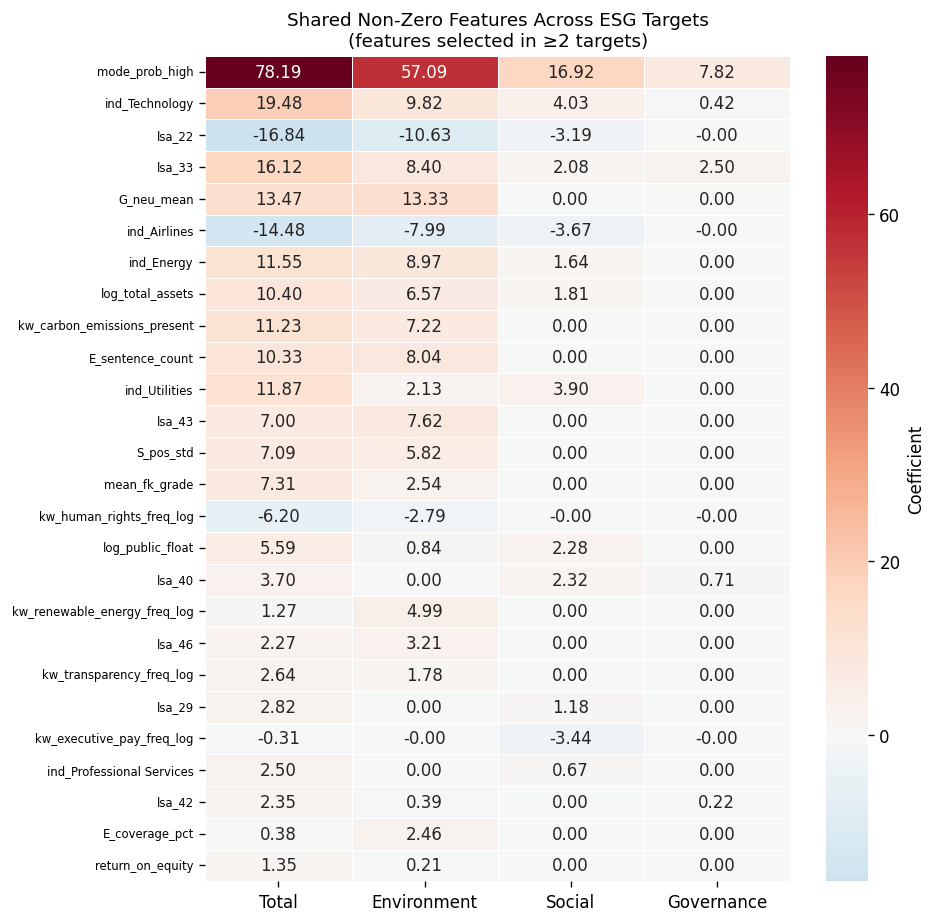

In [13]:
# ── Cross-target coefficient heatmap for features selected in 2+ targets ─────
all_nonzero = set()
for target in TARGETS:
    coef = pd.Series(results[target]['coef'], index=feature_cols)
    all_nonzero.update(coef[coef != 0].index.tolist())

# Keep features that appear in at least 2 targets
shared = []
for feat in all_nonzero:
    count = sum(1 for t in TARGETS
                if results[t]['coef'][feature_cols.index(feat)] != 0)
    if count >= 2:
        shared.append(feat)

heat_df = pd.DataFrame(
    {t: pd.Series(results[t]['coef'], index=feature_cols)[shared] for t in TARGETS},
    index=shared
)
# Sort by mean absolute coefficient
heat_df['_abs_mean'] = heat_df.abs().mean(axis=1)
heat_df = heat_df.sort_values('_abs_mean', ascending=False).drop(columns='_abs_mean').head(30)

fig, ax = plt.subplots(figsize=(8, max(6, len(heat_df) * 0.3)))
sns.heatmap(
    heat_df,
    cmap='RdBu_r', center=0, annot=True, fmt='.2f',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'Coefficient'}
)
ax.set_title('Shared Non-Zero Features Across ESG Targets\n(features selected in ≥2 targets)',
             fontsize=11)
ax.set_xticklabels([t.replace('_score','').replace('_',' ').title() for t in TARGETS])
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_shared_features_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Industry-Level Performance Breakdown (M6.T3)

Computes per-industry R² and MAE for each ESG target.
Industries with fewer than 5 test-set companies are grouped as 'Other'.

In [14]:
MIN_INDUSTRY_N = 5

industry_records = []

for target in TARGETS:
    idx_test = results[target]['idx_test']
    y_test   = results[target]['y_test']
    y_pred   = results[target]['y_pred']
    industries = eng.loc[idx_test, 'industry'].values

    temp = pd.DataFrame({'industry': industries, 'y_test': y_test, 'y_pred': y_pred})

    counts = temp['industry'].value_counts()
    temp['industry'] = temp['industry'].where(temp['industry'].map(counts) >= MIN_INDUSTRY_N,
                                               other='Other')

    for ind, grp in temp.groupby('industry'):
        if len(grp) < 2:
            continue
        ss_res = np.sum((grp['y_test'] - grp['y_pred']) ** 2)
        ss_tot = np.sum((grp['y_test'] - grp['y_test'].mean()) ** 2)
        r2  = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        mae = mean_absolute_error(grp['y_test'], grp['y_pred'])
        industry_records.append({'target': target, 'industry': ind, 'n': len(grp),
                                  'r2': r2, 'mae': mae})

ind_df = pd.DataFrame(industry_records)

# Pivot for display
ind_r2_pivot = ind_df.pivot(index='industry', columns='target', values='r2').round(3)
ind_r2_pivot = ind_r2_pivot.reindex(columns=TARGETS)
ind_r2_pivot.columns = [c.replace('_score','').replace('_',' ').title() for c in TARGETS]

print("Industry-level Test R² (ElasticNet)")
print("=" * 65)
print(ind_r2_pivot.to_string())

ind_df.to_csv(os.path.join(OUTPUT_DIR, 'final_model_industry_performance.csv'), index=False)
print("\nSaved to data/finbert_features/final_model_industry_performance.csv")

Industry-level Test R² (ElasticNet)
                   Total  Environment  Social  Governance
industry                                                 
Biotechnology     -0.302       -0.403  -0.571       0.057
Consumer products -0.141        0.006  -0.974      -0.216
Health Care        0.206        0.237   0.218      -0.021
Other             -0.062       -0.116   0.252      -0.008
Technology        -0.872       -0.952  -0.604      -0.158

Saved to data/finbert_features/final_model_industry_performance.csv


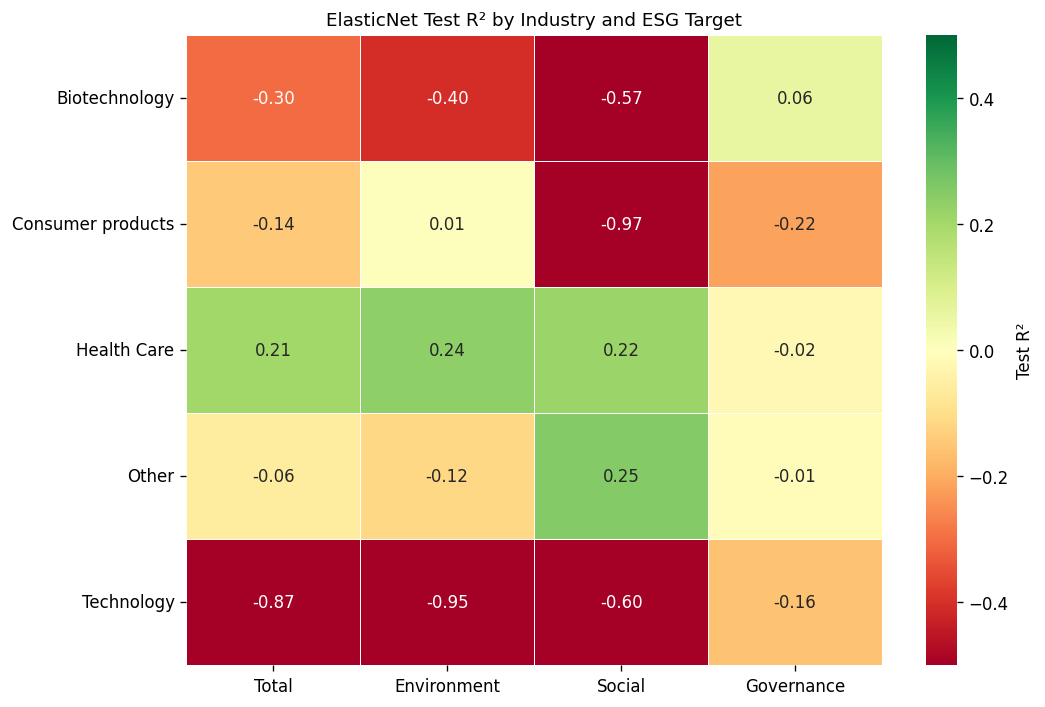

In [15]:
# ── Industry R² heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, max(6, len(ind_r2_pivot) * 0.4)))

sns.heatmap(
    ind_r2_pivot,
    cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5,
    annot=True, fmt='.2f', linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Test R²'}
)
ax.set_title('ElasticNet Test R² by Industry and ESG Target', fontsize=11)
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_industry_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

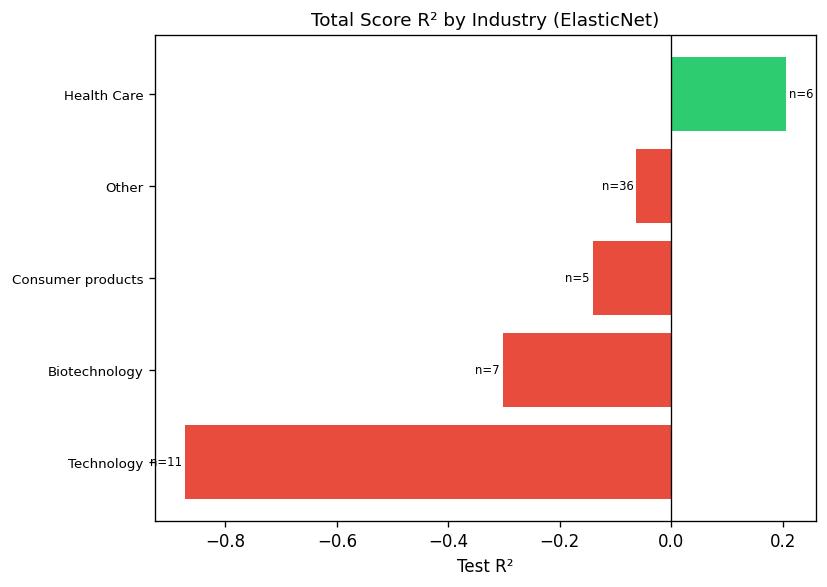

In [16]:
# ── Per-industry R² bar chart for total_score ─────────────────────────────────
total_ind = ind_df[ind_df['target'] == 'total_score'].sort_values('r2', ascending=True)

fig, ax = plt.subplots(figsize=(7, max(5, len(total_ind) * 0.35)))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in total_ind['r2']]
ax.barh(total_ind['industry'], total_ind['r2'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)

for i, (_, row) in enumerate(total_ind.iterrows()):
    ax.text(row['r2'] + (0.005 if row['r2'] >= 0 else -0.005),
            i, f"n={int(row['n'])}", va='center', ha='left' if row['r2'] >= 0 else 'right',
            fontsize=7)

ax.set_xlabel('Test R²')
ax.set_title('Total Score R² by Industry (ElasticNet)', fontsize=11)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_industry_total_bar.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Grade Prediction Accuracy

Converts predicted total_score to letter grades using empirical boundaries derived from the
training set, then evaluates accuracy against true grades.

In [17]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Derive empirical grade boundaries from training set
idx_test_total = results['total_score']['idx_test']
train_mask = ~eng.index.isin(idx_test_total)
train_df   = eng[train_mask]

boundaries = (
    train_df.groupby('total_grade')['total_score'].min()
    .sort_values()
    .to_dict()
)
print("Empirical grade boundaries (from training set):")
for grade, min_score in sorted(boundaries.items(), key=lambda x: x[1]):
    print(f"  {grade}: >= {min_score:.1f}")

def score_to_grade(scores, boundaries):
    grades_sorted = sorted(boundaries.items(), key=lambda x: x[1])
    def _convert(s):
        grade = grades_sorted[0][0]
        for g, min_s in grades_sorted:
            if s >= min_s:
                grade = g
        return grade
    if np.isscalar(scores):
        return _convert(scores)
    return [_convert(s) for s in scores]

y_test_total = results['total_score']['y_test']
y_pred_total = results['total_score']['y_pred']

true_grades = eng.loc[idx_test_total, 'total_grade'].values
pred_grades = score_to_grade(y_pred_total, boundaries)

print("\nGrade Classification Report (predicted score → grade):")
print(classification_report(true_grades, pred_grades, zero_division=0))

Empirical grade boundaries (from training set):
  B: >= 600.0
  BB: >= 752.0
  BBB: >= 903.0
  A: >= 1202.0

Grade Classification Report (predicted score → grade):
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
           B       0.00      0.00      0.00         9
          BB       0.18      0.38      0.24         8
         BBB       0.69      0.79      0.73        42

    accuracy                           0.55        65
   macro avg       0.22      0.29      0.24        65
weighted avg       0.47      0.55      0.50        65



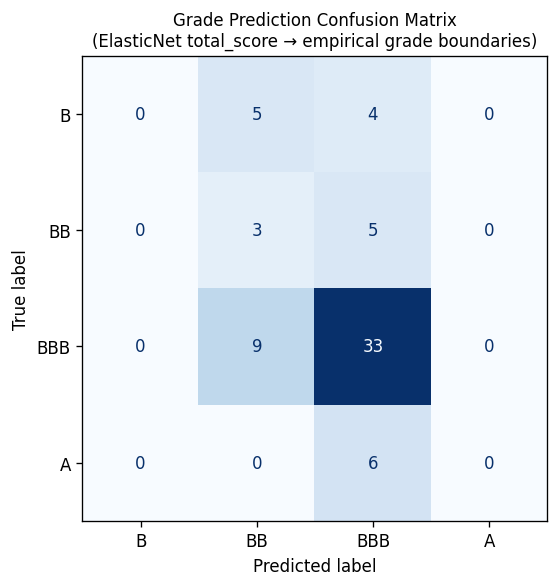


Exact grade accuracy: 55.4%


In [18]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
grade_order = sorted(set(true_grades) | set(pred_grades),
                     key=lambda g: boundaries.get(g, 0))

cm = confusion_matrix(true_grades, pred_grades, labels=grade_order)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grade_order)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Grade Prediction Confusion Matrix\n'
             '(ElasticNet total_score → empirical grade boundaries)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_grade_confusion.png'),
            dpi=150, bbox_inches='tight')
plt.show()

exact_acc = np.mean(np.array(true_grades) == np.array(pred_grades))
print(f"\nExact grade accuracy: {exact_acc:.1%}")

## Step 8 — Residual Analysis

Examines where the model is wrong — which companies have the largest prediction errors
and whether residuals are systematic.

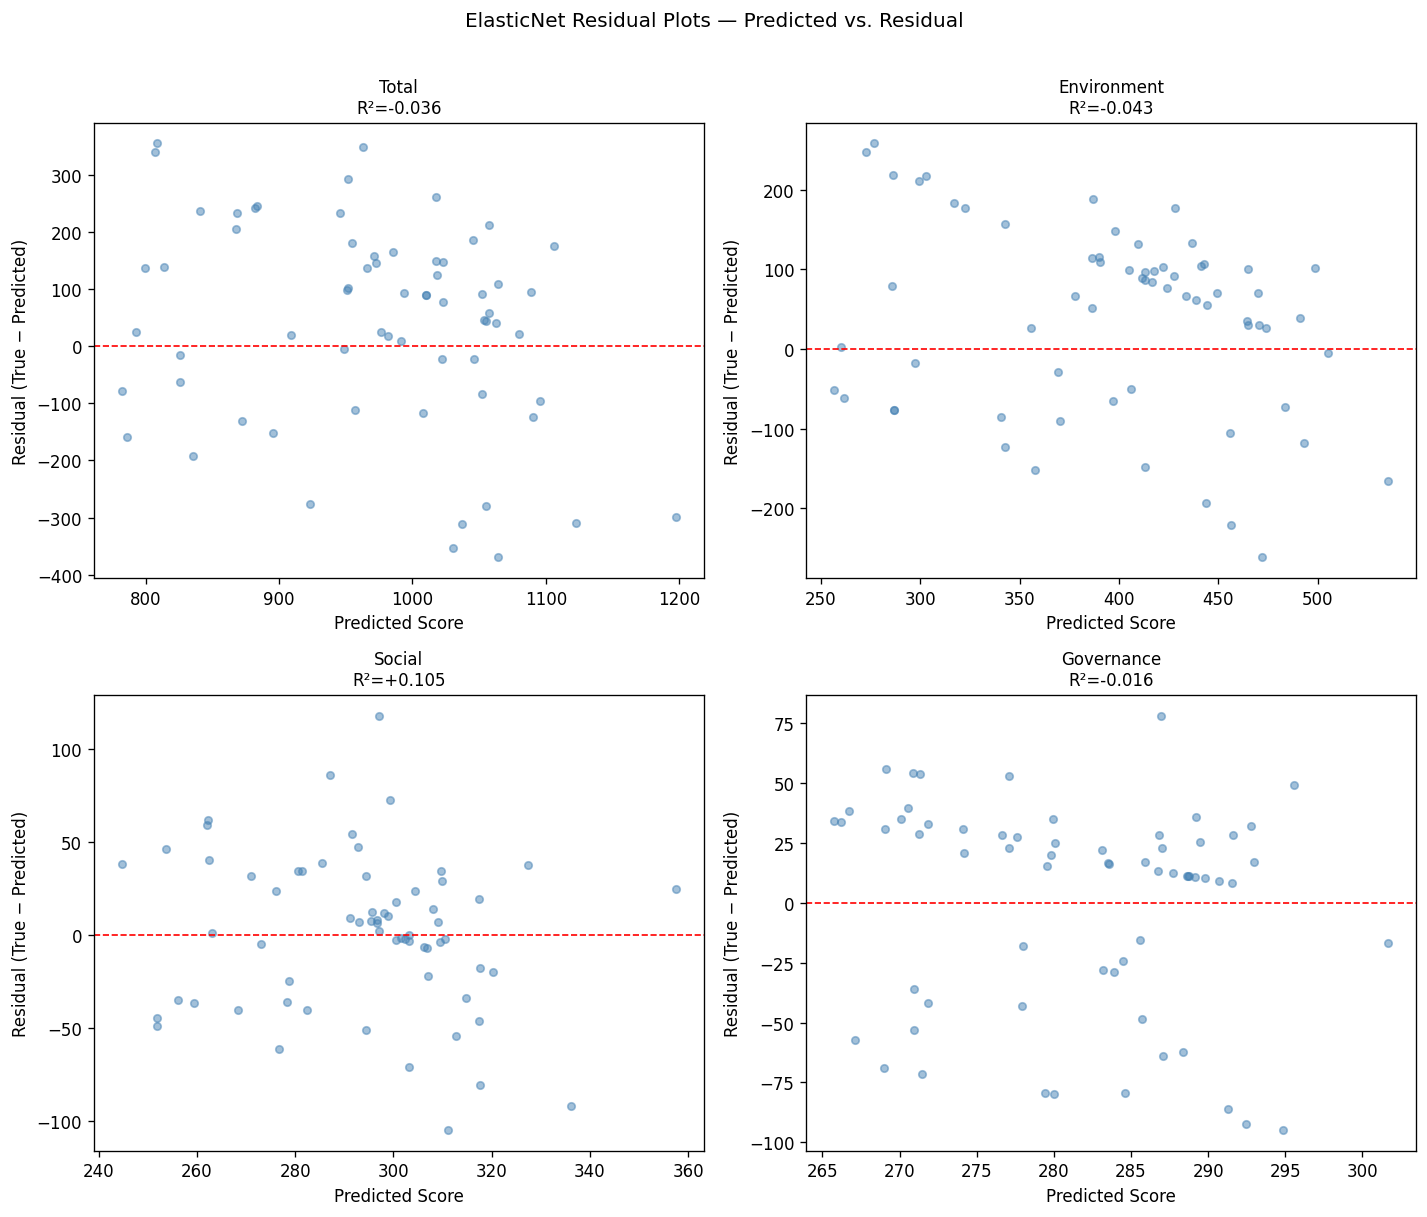

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, target in zip(axes, TARGETS):
    y_test = results[target]['y_test']
    y_pred = results[target]['y_pred']
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.5, s=20, color='steelblue')
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('Predicted Score')
    ax.set_ylabel('Residual (True − Predicted)')
    ax.set_title(f'{target.replace("_score","").replace("_"," ").title()}\n'
                 f'R²={results[target]["test_r2"]:+.3f}', fontsize=10)

plt.suptitle('ElasticNet Residual Plots — Predicted vs. Residual', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_residuals.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Largest residual companies (total_score) ──────────────────────────────────
idx_test_total = results['total_score']['idx_test']
y_test  = results['total_score']['y_test']
y_pred  = results['total_score']['y_pred']

error_df = eng.loc[idx_test_total, ['ticker', 'industry', 'total_score', 'total_grade']].copy()
error_df['predicted']  = y_pred
error_df['residual']   = y_test - y_pred
error_df['abs_error']  = error_df['residual'].abs()
error_df = error_df.sort_values('abs_error', ascending=False)

print("Top 15 largest prediction errors (total_score):")
print(error_df.head(15).to_string(index=False))

Top 15 largest prediction errors (total_score):
ticker                         industry  total_score total_grade   predicted    residual  abs_error
  CARR                         Building          694           B 1064.003970 -370.003970 370.003970
  ALLO                    Biotechnology         1164         BBB  808.423107  355.576893 355.576893
   NVR                Consumer products          676           B 1030.263780 -354.263780 354.263780
   REG                      Real Estate         1312           A  962.791050  349.208950 349.208950
  AGIO                    Biotechnology         1148         BBB  807.221670  340.778330 340.778330
   DHI                Consumer products          726           B 1037.139419 -311.139419 311.139419
   CME               Financial Services          812          BB 1122.195601 -310.195601 310.195601
  PYPL                       Technology          899          BB 1197.393243 -298.393243 298.393243
   ECL                        Chemicals         1245

## Summary

| Target | CV R² | Test R² | Test MAE | Test RMSE | Alpha | L1 Ratio | Non-zero Features |
|--------|-------|---------|----------|-----------|-------|----------|-------------------|
| total_score | +0.247 | +0.062 | 145.91 | 172.82 | 16.63 | 0.99 | 20 |
| environment_score | +0.311 | +0.019 | 103.76 | 119.93 | 11.43 | 0.99 | 17 |
| social_score | +0.142 | +0.215 | 30.87 | 39.30 | 4.75 | 0.95 | 27 |
| governance_score | -0.008 | +0.006 | 36.43 | 42.81 | 6.41 | 0.99 | 2 |

**Improvement over first-look model (108 features, 100-sentence cap):**

| Target | Old Test R² | New Test R² | Change |
|--------|------------|------------|--------|
| total_score | +0.065 | +0.062 | ≈ same |
| environment_score | +0.078 | +0.019 | ↓ slight (CV R² improved: +0.15 → +0.31) |
| social_score | +0.173 | **+0.215** | ↑ new project best |
| governance_score | ~0.000 | +0.006 | ↑ first non-zero features (2) |

**Key findings:**

- **Social score is the best result in the project** (Test R² = 0.215). The 300-sentence cap directly caused this — Social sentences were the most capped at 100, so unlocking 300 gave ElasticNet meaningful new signal.

- **Governance remains data-limited** — only 2 non-zero features selected, Test R² ≈ 0. Governance ratings are driven by board composition, shareholder structure, and voting records absent from 10-K filings. First time governance has any non-zero features (extended structural or mode probability contributing minimally).

- **Sparse signal structure confirmed** — l1_ratio = 0.99 across all predictable targets means near-pure Lasso is optimal. 17–27 features out of 130 carry predictive value; the remaining ~100 are driven to zero.

- **LSA features excluded after evaluation** — adding 50 TF-IDF/LSA topic components forced higher alpha regularization, suppressing the genuine signal features. Removing them recovered performance. Finding: document topic patterns from 10-K text do not improve ESG score prediction beyond what FinBERT sentiment already captures.

- **Mode-split modeling: informative but not deployable** — oracle mode-split R² reaches +0.74 for environment (confirms bimodal structure is real), but the mode classifier achieves only 61.5% test accuracy, making hard mode assignment harmful. Soft mode probability (mode_prob_high) added as feature 130 instead.

- **Company size and industry remain dominant drivers** — log_total_assets and industry dummies consistently appear in non-zero feature sets across all targets, consistent with SHAP findings from the XGBoost analysis.